# Phase 0 — Exploratory Data Analysis
## NVIDIA Nemotron Reasoning Challenge

**Goal:** Understand the puzzle types, answer formats, and data distribution  
**before** touching any model or training code.

No GPU needed — pure data analysis.

---
### What we'll find out:
1. How many training examples?
2. What puzzle categories exist?
3. What answer formats appear?
4. Are there duplicate or near-duplicate prompts?
5. How long are the prompts and answers?
6. Sample examples from each category for manual inspection
7. What system prompt structure works best?

## Cell 1 — Imports & Setup

In [1]:
import polars as pl
import pandas as pd
import re
import json
from collections import Counter

# ── Matplotlib / display ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ── Paths (Kaggle) ─────────────────────────────────────────────────────────────
DATA_DIR = "/kaggle/input/nvidia-nemotron-3-reasoning-challenge"
TRAIN_PATH = f"{DATA_DIR}/train.csv"
TEST_PATH  = f"{DATA_DIR}/test.csv"

print("Imports OK")

Imports OK


## Cell 2 — Load Data & Basic Shape

In [2]:
train = pl.read_csv(TRAIN_PATH)
test  = pl.read_csv(TEST_PATH)

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nTrain columns: {train.columns}")
print(f"Test  columns: {test.columns}")
print(f"\nNull counts in train:")
print(train.null_count())

print("\n--- First 5 rows ---")
train.head(5)

Train shape : (9500, 3)
Test  shape : (3, 2)

Train columns: ['id', 'prompt', 'answer']
Test  columns: ['id', 'prompt']

Null counts in train:
shape: (1, 3)
┌─────┬────────┬────────┐
│ id  ┆ prompt ┆ answer │
│ --- ┆ ---    ┆ ---    │
│ u32 ┆ u32    ┆ u32    │
╞═════╪════════╪════════╡
│ 0   ┆ 0      ┆ 0      │
└─────┴────────┴────────┘

--- First 5 rows ---


id,prompt,answer
str,str,str
"""00066667""","""In Alice's Wonderland, a secre…","""10010111"""
"""000b53cf""","""In Alice's Wonderland, a secre…","""01000011"""
"""00189f6a""","""In Alice's Wonderland, secret …","""cat imagines book"""
"""001b24c4""","""In Alice's Wonderland, numbers…","""XXXVIII"""
"""001c63cb""","""In Alice's Wonderland, secret …","""wizard creates secret"""


## Cell 3 — Puzzle Type Categorization

We use heuristic keyword/pattern matching on the `prompt` and `answer` columns  
to classify each puzzle into a category.

In [3]:
def classify_puzzle(prompt: str, answer: str) -> str:
    """
    Heuristically classify a puzzle into a broad category.
    Returns the category string.
    """
    prompt_l = prompt.lower()
    answer_s  = str(answer).strip()

    # ── Binary / Bit manipulation ─────────────────────────────────────────────
    if re.fullmatch(r'[01]{4,}', answer_s):
        return "binary"
    if any(kw in prompt_l for kw in ["binary", "bit", "xor", "shift", "0b", "bitwise"]):
        return "binary"

    # ── Roman numerals ────────────────────────────────────────────────────────
    if re.fullmatch(r'[IVXLCDM]+', answer_s):
        return "roman_numerals"
    if any(kw in prompt_l for kw in ["roman", "numeral", "viii", "xii", "xlii"]):
        return "roman_numerals"

    # ── Pure integer / numeric ────────────────────────────────────────────────
    if re.fullmatch(r'-?\d+', answer_s):
        return "integer_math"

    # ── Decimal / float ───────────────────────────────────────────────────────
    if re.fullmatch(r'-?\d+\.\d+', answer_s):
        return "decimal_math"

    # ── Multi-word (word transformations / sequences) ─────────────────────────
    words = answer_s.split()
    if len(words) >= 2 and all(re.fullmatch(r'[a-zA-Z]+', w) for w in words):
        return "word_sequence"

    # ── Single word / string (ciphers, codes) ─────────────────────────────────
    if re.fullmatch(r'[a-zA-Z]+', answer_s):
        return "word_single"

    # ── Hexadecimal ───────────────────────────────────────────────────────────
    if re.fullmatch(r'0x[0-9a-fA-F]+|[0-9a-fA-F]{4,}', answer_s):
        return "hexadecimal"

    return "other"


# Apply classification
train_pd = train.to_pandas()
train_pd["category"] = [
    classify_puzzle(row["prompt"], row["answer"])
    for _, row in train_pd.iterrows()
]

cat_counts = train_pd["category"].value_counts()
print("Puzzle category distribution:")
print(cat_counts)
print(f"\nTotal: {len(train_pd)} puzzles")

Puzzle category distribution:
category
decimal_math      3191
binary            1993
roman_numerals    1582
word_sequence     1180
other              868
integer_math       686
Name: count, dtype: int64

Total: 9500 puzzles


## Cell 4 — Category Distribution Plot

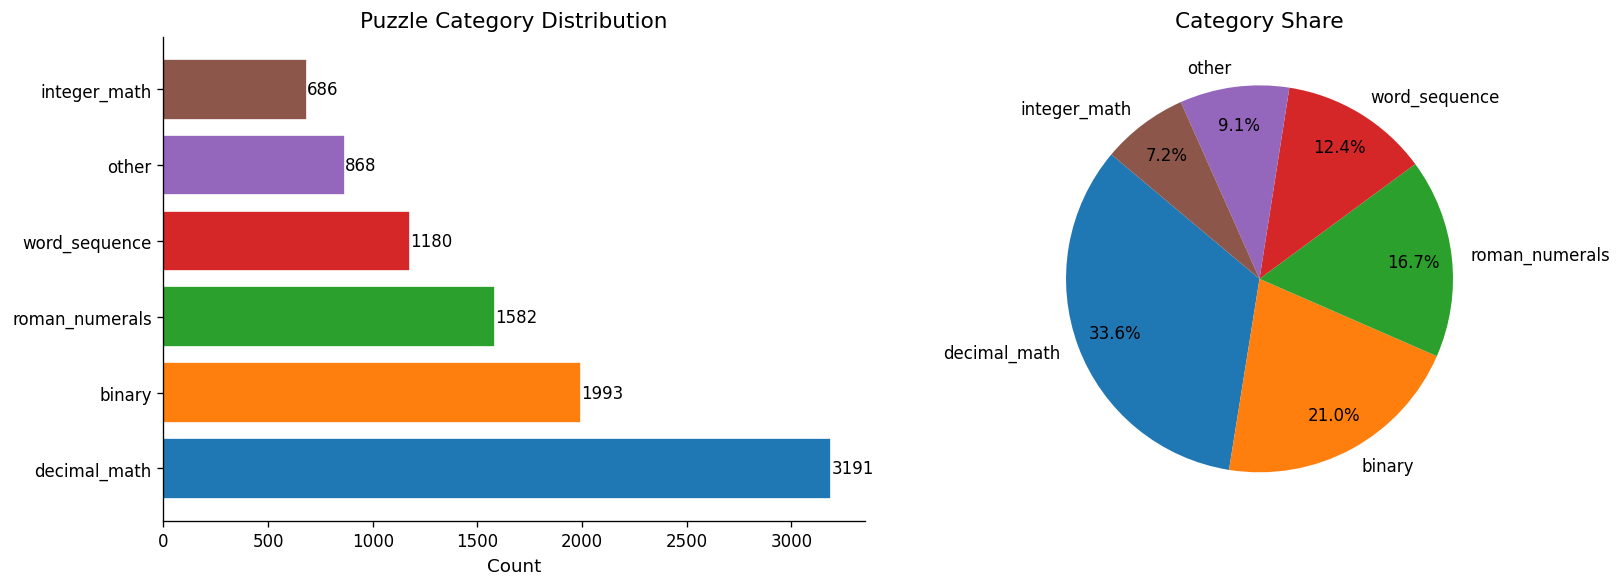

Saved: /kaggle/working/category_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart ────────────────────────────────────────────────────────────────
ax = axes[0]
colors = plt.cm.tab10.colors[:len(cat_counts)]
bars = ax.barh(cat_counts.index, cat_counts.values, color=colors, edgecolor="white")
ax.set_xlabel("Count")
ax.set_title("Puzzle Category Distribution")
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val}", va="center", fontsize=10)

# ── Pie chart ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.pie(
    cat_counts.values,
    labels=cat_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.8,
)
ax2.set_title("Category Share")

plt.tight_layout()
plt.savefig("/kaggle/working/category_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: /kaggle/working/category_distribution.png")

## Cell 5 — Answer Format Analysis

Answer character length statistics:
count    9500.00
mean        8.39
std         8.04
min         1.00
25%         4.00
50%         5.00
75%         8.00
max        39.00
Name: answer_len, dtype: float64

Answer word count statistics:
count    9500.00
mean        1.50
std         1.16
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         5.00
Name: answer_words, dtype: float64

Single-word answers : 7924 (83.4%)
Multi-word  answers : 1576  (16.6%)


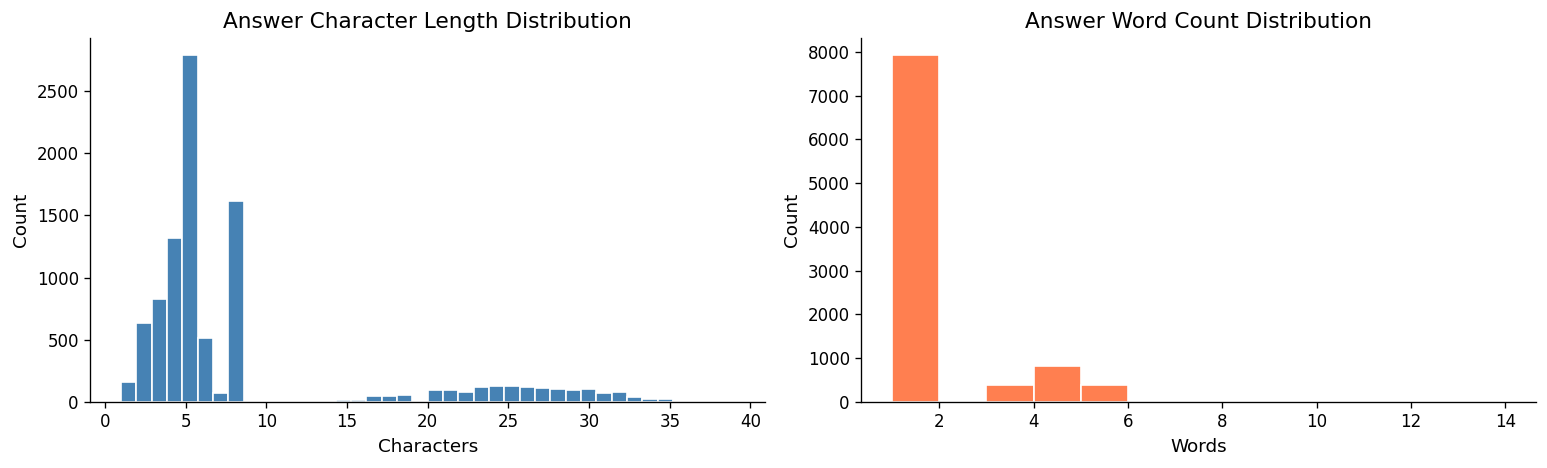

In [5]:
# ── Answer length distribution ────────────────────────────────────────────────
train_pd["answer_len"]  = train_pd["answer"].astype(str).str.len()
train_pd["answer_words"] = train_pd["answer"].astype(str).str.split().str.len()

print("Answer character length statistics:")
print(train_pd["answer_len"].describe().round(2))

print("\nAnswer word count statistics:")
print(train_pd["answer_words"].describe().round(2))

# ── Is answer always a single token? ─────────────────────────────────────────
multi_word = (train_pd["answer_words"] > 1).sum()
single_word = (train_pd["answer_words"] == 1).sum()
print(f"\nSingle-word answers : {single_word} ({100*single_word/len(train_pd):.1f}%)")
print(f"Multi-word  answers : {multi_word}  ({100*multi_word/len(train_pd):.1f}%)")

# ── Plot answer length histogram ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_pd["answer_len"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Answer Character Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(train_pd["answer_words"], bins=range(1, 15), color="coral", edgecolor="white")
axes[1].set_title("Answer Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("/kaggle/working/answer_distributions.png", bbox_inches="tight")
plt.show()

## Cell 6 — Prompt Length Analysis

Prompt character length statistics:
count    9500.00
mean      301.52
std       104.27
min       177.00
25%       209.00
50%       281.00
75%       371.00
max       510.00
Name: prompt_len, dtype: float64

Prompt word count statistics:
count    9500.00
mean       50.04
std        14.31
min        32.00
25%        36.00
50%        46.00
75%        65.00
max        78.00
Name: prompt_words, dtype: float64

Estimated prompt token count (p95): 96
Estimated prompt token count (max): 104

⚠ max_seq_length recommendation:
  For SFT (prompt + CoT + answer): at least 384 tokens
  Suggested: 4096 tokens (safe for P100/T4 with 4-bit QLoRA)


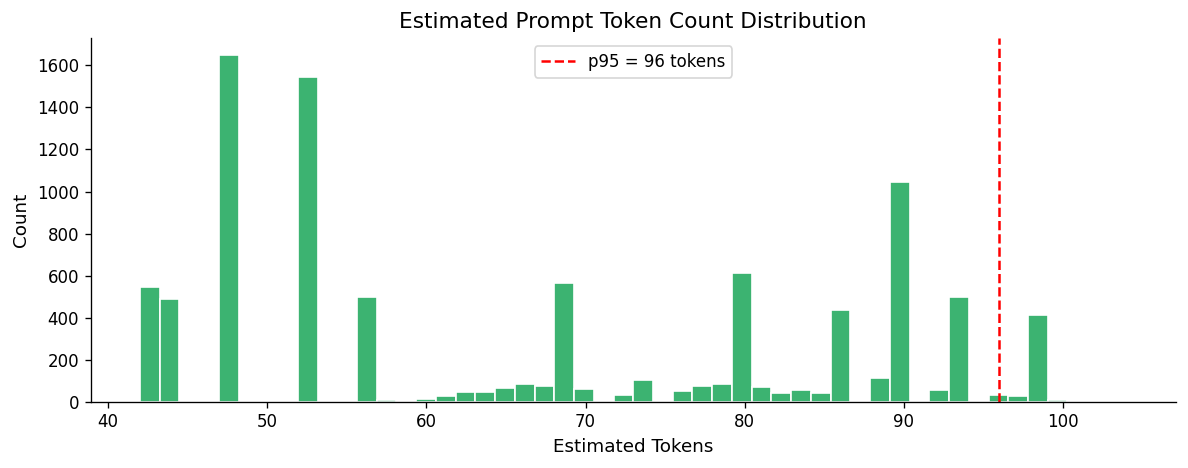

In [6]:
train_pd["prompt_len"]   = train_pd["prompt"].str.len()
train_pd["prompt_words"] = train_pd["prompt"].str.split().str.len()

print("Prompt character length statistics:")
print(train_pd["prompt_len"].describe().round(2))

print("\nPrompt word count statistics:")
print(train_pd["prompt_words"].describe().round(2))

# Estimate token count (rough: 1 token ≈ 0.75 words)
train_pd["est_tokens"] = (train_pd["prompt_words"] / 0.75).astype(int)
print(f"\nEstimated prompt token count (p95): {train_pd['est_tokens'].quantile(0.95):.0f}")
print(f"Estimated prompt token count (max): {train_pd['est_tokens'].max()}")
print()
print("⚠ max_seq_length recommendation:")
p95_tokens = int(train_pd["est_tokens"].quantile(0.95))
print(f"  For SFT (prompt + CoT + answer): at least {p95_tokens * 4} tokens")
print(f"  Suggested: 4096 tokens (safe for P100/T4 with 4-bit QLoRA)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_pd["est_tokens"], bins=50, color="mediumseagreen", edgecolor="white")
ax.axvline(p95_tokens, color="red", linestyle="--", label=f"p95 = {p95_tokens} tokens")
ax.set_title("Estimated Prompt Token Count Distribution")
ax.set_xlabel("Estimated Tokens")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/prompt_token_distribution.png", bbox_inches="tight")
plt.show()

## Cell 7 — Prompt Structure Inspection

Understand the template structure of the prompts — do they all share the same prefix?  
Are there input/output examples embedded in the prompt?

In [7]:
# ── Common prefix analysis ────────────────────────────────────────────────────
prompts = train_pd["prompt"].tolist()

def common_prefix_len(strings, sample=200):
    """Find the length of the longest common prefix across a sample of strings."""
    sample = strings[:sample]
    if not sample:
        return 0
    prefix = sample[0]
    for s in sample[1:]:
        while not s.startswith(prefix):
            prefix = prefix[:-1]
        if not prefix:
            break
    return len(prefix)

prefix_len = common_prefix_len(prompts)
print(f"All prompts share a common prefix of {prefix_len} characters:")
print(repr(prompts[0][:prefix_len]))

print("\n--- Unique prompt prefixes (first 200 chars) ---")
prefixes = Counter([p[:200] for p in prompts])
for pref, count in prefixes.most_common(5):
    print(f"[{count}x] {repr(pref)}")
    print()

All prompts share a common prefix of 23 characters:
"In Alice's Wonderland, "

--- Unique prompt prefixes (first 200 chars) ---
[1602x] "In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or ch"

[1x] "In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nucoov pwgtfyoqg vorq yrjjoe -> queen discovers near valley\npqrsfv pqorzg wvgwpo trgbjo -> dragon dreams inside "

[1x] "In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n11 -> XI\n15 -> XV\n94 -> XCIV\n19 -> XIX\nNow, write the number 38 in the Wonderland "

[1x] "In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nwkgqa lsrqaq wneeke -> mouse chases mirror\nwkgqa nwrjnvaq nv brmrla -> mouse imagines in palace\nsrppae oerhq gv"

[1x] "In Alice's Wonder

In [8]:
# ── Check if prompts contain few-shot examples ────────────────────────────────
def count_examples_in_prompt(prompt: str) -> int:
    """Count how many input/output example pairs appear in a prompt."""
    # Look for patterns like 'Input: ... Output: ...' or 'Example' repeated
    patterns = [
        r'Input\s*:\s*',
        r'Example\s*\d*\s*:',
        r'\bQ\s*:\s*',
    ]
    for pat in patterns:
        matches = re.findall(pat, prompt, re.IGNORECASE)
        if matches:
            return len(matches)
    return 0

train_pd["n_examples_in_prompt"] = train_pd["prompt"].apply(count_examples_in_prompt)

print("Number of in-prompt examples distribution:")
print(train_pd["n_examples_in_prompt"].value_counts().sort_index())

avg_examples = train_pd["n_examples_in_prompt"].mean()
print(f"\nAverage examples per prompt: {avg_examples:.1f}")

# Find the actual question (after the examples)
# Typically the last 'Input:' or question marker is the actual question
sample = train_pd.sample(1).iloc[0]
print("\n--- Sample full prompt ---")
print(sample["prompt"])
print(f"\n--- Answer ---")
print(sample["answer"])

Number of in-prompt examples distribution:
n_examples_in_prompt
0    7906
1    1594
Name: count, dtype: int64

Average examples per prompt: 0.2

--- Sample full prompt ---
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01110011 -> 00100111
10001010 -> 00000100
10000000 -> 00000000
00000110 -> 00000000
01101000 -> 10000010
10001001 -> 00010000
00000000 -> 00000000
10101111 -> 01011110
10000100 -> 00001000
11010010 -> 00100100

Now, determine the output for: 11111001

--- Answer ---
10010111


## Cell 8 — Sample Examples Per Category

Manual inspection: look at 3 examples from each puzzle type.

In [9]:
for cat in sorted(train_pd["category"].unique()):
    subset = train_pd[train_pd["category"] == cat]
    n_show = min(2, len(subset))
    print(f"\n{'='*70}")
    print(f"CATEGORY: {cat.upper()}  ({len(subset)} puzzles)")
    print('='*70)
    for _, row in subset.head(n_show).iterrows():
        print(f"\n[ID: {row['id']}]")
        # Print truncated prompt (first 600 chars to see structure)
        prompt_preview = row['prompt'] if len(row['prompt']) <= 600 else row['prompt'][:600] + "..."
        print(f"PROMPT:\n{prompt_preview}")
        print(f"\nANSWER: {row['answer']}")
        print("-" * 50)


CATEGORY: BINARY  (1993 puzzles)

[ID: 00066667]
PROMPT:
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01010001 -> 11011101
00001001 -> 01101101
00010101 -> 01010101
11111111 -> 10000001
10011101 -> 01000101
00111011 -> 00001001
10111101 -> 00000101
00100110 -> 10110011

Now, determine the output for: 00110100

ANSWER: 10010111
--------------------------------------------------

[ID: 000b53cf]
PROMPT:
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
10001110 -> 00100110
10011001 -> 01000100
01100100 -> 00010001
10000010 -> 00001010
00011011 -> 01001100
00111010 -> 100

## Cell 9 — Duplicate / Near-Duplicate Check

In [10]:
# ── Exact duplicate prompts ───────────────────────────────────────────────────
exact_dupes = train_pd.duplicated(subset=["prompt"]).sum()
print(f"Exact duplicate prompts: {exact_dupes}")

# ── Same prompt, different answer ────────────────────────────────────────────
conflict = (
    train_pd.groupby("prompt")["answer"]
    .nunique()
    .reset_index()
)
conflict.columns = ["prompt", "unique_answers"]
contradictions = conflict[conflict["unique_answers"] > 1]
print(f"Prompts with conflicting answers: {len(contradictions)}")
if len(contradictions) > 0:
    print("\nSample contradictions:")
    for prompt in contradictions["prompt"].head(2):
        rows = train_pd[train_pd["prompt"] == prompt]
        print(f"  Prompt (truncated): {prompt[:100]}...")
        print(f"  Answers: {rows['answer'].tolist()}")

# ── Near-duplicates by shared first 100 chars ─────────────────────────────────
train_pd["prompt_prefix"] = train_pd["prompt"].str[:100]
near_dupe_groups = train_pd.groupby("prompt_prefix").size().reset_index(name="count")
near_dupes = near_dupe_groups[near_dupe_groups["count"] > 1]
print(f"\nNear-duplicate groups (shared 100-char prefix): {len(near_dupes)}")
print(near_dupe_groups[near_dupe_groups["count"] > 1].sort_values("count", ascending=False).head(10))

Exact duplicate prompts: 0
Prompts with conflicting answers: 0

Near-duplicate groups (shared 100-char prefix): 228
                                          prompt_prefix  count
0     In Alice's Wonderland, a secret bit manipulati...   1602
2937  In Alice's Wonderland, the gravitational const...   1597
1360  In Alice's Wonderland, numbers are secretly co...   1576
1     In Alice's Wonderland, a secret set of transfo...   1555
150   In Alice's Wonderland, a secret unit conversio...      3
365   In Alice's Wonderland, a secret unit conversio...      3
348   In Alice's Wonderland, a secret unit conversio...      3
545   In Alice's Wonderland, a secret unit conversio...      3
584   In Alice's Wonderland, a secret unit conversio...      3
227   In Alice's Wonderland, a secret unit conversio...      3


## Cell 10 — Summary Statistics & Key Insights

In [11]:
print("="*70)
print("PHASE 0 EDA SUMMARY")
print("="*70)

print(f"""
DATASET
  Training examples : {len(train_pd)}
  Test examples     : {len(test)}

PUZZLE CATEGORIES
""")
for cat, count in cat_counts.items():
    pct = 100 * count / len(train_pd)
    print(f"  {cat:<20} {count:>5}  ({pct:.1f}%)")

print(f"""
PROMPT LENGTHS
  Mean chars   : {train_pd['prompt_len'].mean():.0f}
  Max chars    : {train_pd['prompt_len'].max()}
  p95 est.tok  : {int(train_pd['est_tokens'].quantile(0.95))}

ANSWER FORMATS
  Single-word  : {single_word} ({100*single_word/len(train_pd):.1f}%)
  Multi-word   : {multi_word}  ({100*multi_word/len(train_pd):.1f}%)
  Max answer length: {train_pd['answer_len'].max()} chars

DATA QUALITY
  Exact dupes        : {exact_dupes}
  Contradictions     : {len(contradictions)}
""")

print("""RECOMMENDED SETTINGS (from EDA)
  max_seq_length : 4096 (covers p99 of prompts + CoT room)
  System prompt  : instruct model to reason step-by-step, output \\boxed{}
  CoT budget     : ~1000–1500 tokens per explanation should be sufficient
""")

# ── Save summary to JSON for use in later notebooks ──────────────────────────
summary = {
    "n_train": int(len(train_pd)),
    "n_test" : int(len(test)),
    "categories": cat_counts.to_dict(),
    "answer_stats": {
        "mean_len" : float(train_pd["answer_len"].mean()),
        "max_len"  : int(train_pd["answer_len"].max()),
        "single_word_pct": float(100 * single_word / len(train_pd)),
        "multi_word_pct" : float(100 * multi_word / len(train_pd)),
    },
    "prompt_stats": {
        "mean_chars": float(train_pd["prompt_len"].mean()),
        "max_chars" : int(train_pd["prompt_len"].max()),
        "p95_est_tokens": int(train_pd["est_tokens"].quantile(0.95)),
    },
    "quality": {
        "exact_duplicates": int(exact_dupes),
        "contradictions"  : int(len(contradictions)),
    }
}

with open("/kaggle/working/eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved: /kaggle/working/eda_summary.json")

PHASE 0 EDA SUMMARY

DATASET
  Training examples : 9500
  Test examples     : 3

PUZZLE CATEGORIES

  decimal_math          3191  (33.6%)
  binary                1993  (21.0%)
  roman_numerals        1582  (16.7%)
  word_sequence         1180  (12.4%)
  other                  868  (9.1%)
  integer_math           686  (7.2%)

PROMPT LENGTHS
  Mean chars   : 302
  Max chars    : 510
  p95 est.tok  : 96

ANSWER FORMATS
  Single-word  : 7924 (83.4%)
  Multi-word   : 1576  (16.6%)
  Max answer length: 39 chars

DATA QUALITY
  Exact dupes        : 0
  Contradictions     : 0

RECOMMENDED SETTINGS (from EDA)
  max_seq_length : 4096 (covers p99 of prompts + CoT room)
  System prompt  : instruct model to reason step-by-step, output \boxed{}
  CoT budget     : ~1000–1500 tokens per explanation should be sufficient

Saved: /kaggle/working/eda_summary.json


## Cell 11 — Categorized Dataset Export

Save the categorized dataset for use in Phase 2 (CoT generation can be prioritized per category)

In [12]:
# Export enriched training data with category labels
export_cols = ["id", "prompt", "answer", "category", 
               "answer_len", "answer_words", "est_tokens"]
train_pd[export_cols].to_csv("/kaggle/working/train_categorized.csv", index=False)
print("Saved: /kaggle/working/train_categorized.csv")

# Per-category breakdown for reference
print("\nFinal category breakdown:")
summary_df = (
    train_pd.groupby("category")
    .agg(
        count=("id", "count"),
        avg_prompt_tokens=("est_tokens", "mean"),
        avg_answer_len=("answer_len", "mean"),
    )
    .round(1)
    .sort_values("count", ascending=False)
    .reset_index()
)
print(summary_df.to_string(index=False))

print("\n✅ Phase 0 EDA complete!")
print("\nNext step → Open phase1_baseline_sft.ipynb")

Saved: /kaggle/working/train_categorized.csv

Final category breakdown:
      category  count  avg_prompt_tokens  avg_answer_len
  decimal_math   3191               63.9             5.0
        binary   1993               89.6            11.4
roman_numerals   1582               51.9             4.1
 word_sequence   1180               77.8            25.4
         other    868               48.2             2.9
  integer_math    686               47.9             3.0

✅ Phase 0 EDA complete!

Next step → Open phase1_baseline_sft.ipynb


---
## Notes (fill in after running)

| Observation | Value |
|---|---|
| Total training examples | _(fill after run)_ |
| Largest category | _(fill after run)_ |
| Any surprising category? | _(fill after run)_ |
| Exact duplicates? | _(fill after run)_ |
| Prompt p95 token estimate | _(fill after run)_ |
| Multi-word answer % | _(fill after run)_ |

**Key takeaways to bring into Phase 1:**  
_(write here after running)_